# Notebook 02 – Baseline Models (Linear Regression)

## Motivation (from EDA)

In [01_eda.ipynb](01_eda.ipynb) we discovered that the sales data contains:
- A **smooth upward trend** and **strong seasonal patterns** (monthly & weekly cycles)
- **Right-skewed** but otherwise regular distributions across all 500 series
- Relatively **low complexity** — rolling averages showed the underlying signal is smooth

Before training any LSTM, we need a **simple statistical baseline** to answer a key question from the project proposal:

> *"Compare the efficiency difference between our optimised LSTM and simple, fast statistical models."*

**Linear Regression** serves this purpose. It treats the 30-day sliding window as 30 flat features and fits a single linear mapping to the next day's sales. It cannot model non-linear or temporal dependencies — so any gain the LSTM achieves over this baseline represents the value added by the network's sequential memory.

We measure:
- **MSE & MAPE** — accuracy (same metrics as the paper)
- **Training time** — efficiency baseline
- **Parameter count** — model size baseline

In [9]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

from src.data_preprocessing import load_and_preprocess
from src.evaluate import mean_absolute_percentage_error

sns.set_theme(style='whitegrid')
%matplotlib inline

BLUE   = '#4C72B0'
ORANGE = '#DD8452'

## 1. Load Preprocessed Data

We use the same preprocessing pipeline as the LSTM notebooks: **Min-Max scaling** (fitted on training data only, as justified by the EDA's finding of proportional mean-std relationships) and a **30-day sliding window** (justified by the autocorrelation analysis showing significant correlation out to ~30 lags with 7-day periodicity).

Note: The Kaggle ``test.csv`` has no ``sales`` column (it is for competition submissions). We therefore use ``train.csv`` only and split it chronologically into train / validation / test sets.

For Linear Regression, we **flatten** each (30, 1) window into a 30-element feature vector — the model sees 30 lag features but has no concept of their sequential order.

In [10]:
X_train, X_val, X_test, y_train, y_val, y_test, scaler = load_and_preprocess(
    csv_path='../data/raw/train.csv',
    window_size=30,
)

# Flatten: (N, 30, 1) → (N, 30) so sklearn can use it
X_tr_flat = X_train.reshape(len(X_train), -1)
X_va_flat = X_val.reshape(len(X_val), -1)
X_te_flat = X_test.reshape(len(X_test), -1)

print(f'Train:      {X_tr_flat.shape}')
print(f'Validation: {X_va_flat.shape}')
print(f'Test:       {X_te_flat.shape}')

Train:      (727000, 30)
Validation: (81000, 30)
Test:       (90000, 30)


## 2. Train Linear Regression

Linear Regression fits: $\hat{y} = w_1 x_1 + w_2 x_2 + \ldots + w_{30} x_{30} + b$

where each $x_i$ is the scaled sales from day $i$ in the 30-day window. It learns 31 parameters total (30 coefficients + 1 intercept) — orders of magnitude fewer than even the smallest LSTM-16 (1,857 parameters).

In [11]:
t0 = time.perf_counter()
lr_model = LinearRegression()
lr_model.fit(X_tr_flat, y_train)
train_time = time.perf_counter() - t0

# Predictions on validation and test sets (scaled space)
y_val_pred_scaled  = lr_model.predict(X_va_flat)
y_test_pred_scaled = lr_model.predict(X_te_flat)

# Inverse-transform to original sales scale
y_val_pred  = scaler.inverse_transform(y_val_pred_scaled.reshape(-1, 1)).flatten()
y_val_true  = scaler.inverse_transform(y_val.reshape(-1, 1)).flatten()
y_test_pred = scaler.inverse_transform(y_test_pred_scaled.reshape(-1, 1)).flatten()
y_test_true = scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()

# Metrics
val_mse   = mean_squared_error(y_val_true, y_val_pred)
val_mape  = mean_absolute_percentage_error(y_val_true, y_val_pred)
test_mse  = mean_squared_error(y_test_true, y_test_pred)
test_mape = mean_absolute_percentage_error(y_test_true, y_test_pred)

print(f'Training time : {train_time*1000:.1f} ms')
print(f'Parameters    : {X_tr_flat.shape[1] + 1}')
print()
print(f'Validation MSE  : {val_mse:.4f}')
print(f'Validation MAPE : {val_mape:.2f} %')
print()
print(f'Test MSE        : {test_mse:.4f}')
print(f'Test MAPE       : {test_mape:.2f} %')

Training time : 378.3 ms
Parameters    : 31

Validation MSE  : 85.3043
Validation MAPE : 13.99 %

Test MSE        : 94.1568
Test MAPE       : 14.82 %


### Insight — Linear Regression Performance

Linear Regression trains almost instantly and produces a MAPE baseline. However, recall from the EDA:

- The data has **non-linear seasonal patterns** (summer peaks, winter troughs) and a **trend** — a linear model on raw lag features cannot capture curved relationships.
- The **weekly 7-day cycle** visible in the autocorrelation means certain lag positions (7, 14, 21, 28) are far more informative than others — LR treats them all equally with independent weights, whereas an LSTM processes them sequentially and can learn position-dependent importance.

This MAPE establishes the **accuracy floor**. Any LSTM variant that cannot beat this number would add complexity without adding value.

## 3. Visualise Predictions vs Actuals

The EDA showed that individual series have **trend + seasonality + noise**. Let's see how well (or poorly) LR captures these components.

Test windows per store-item group: 180


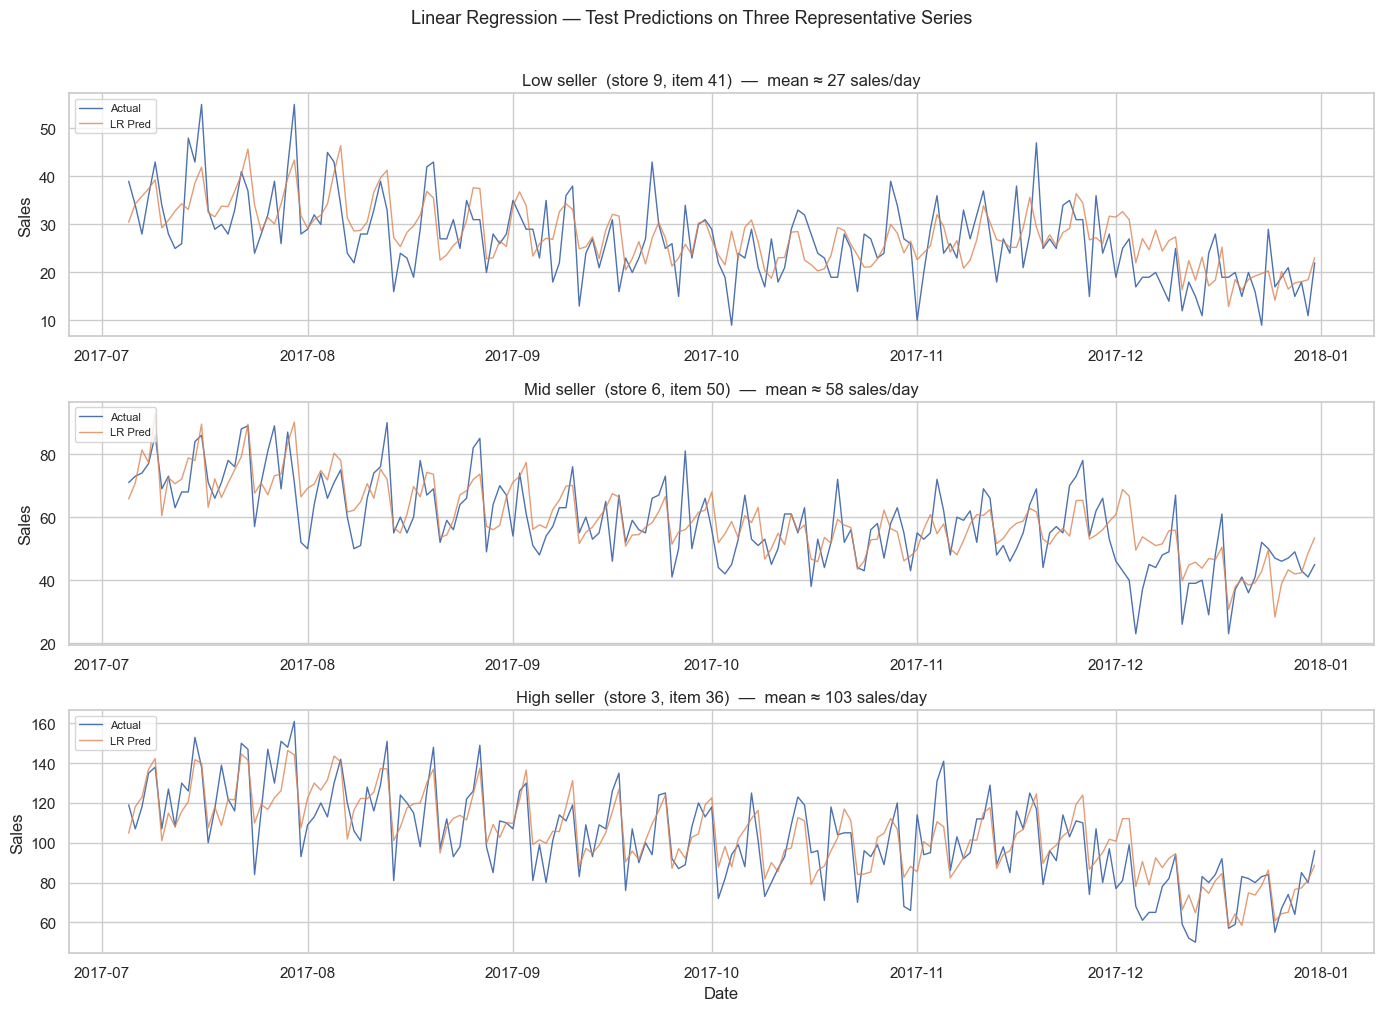

In [12]:
# --- How many test windows per group? ---
# Each of 500 groups contributes the same number of test windows.
n_per_group = len(y_test_true) // 500
print(f'Test windows per store-item group: {n_per_group}')

# Pick 3 representative groups: low / medium / high average sales
group_means = [y_test_true[i * n_per_group : (i+1) * n_per_group].mean()
               for i in range(500)]
sorted_idx = np.argsort(group_means)
picks = {
    'Low seller':  sorted_idx[50],       # ~10th percentile
    'Mid seller':  sorted_idx[250],      # ~50th percentile
    'High seller': sorted_idx[450],      # ~90th percentile
}

# Recover the date axis for each group's test window
df_raw = pd.read_csv('../data/raw/train.csv', parse_dates=['date'])
df_raw = df_raw.sort_values(['store', 'item', 'date']).reset_index(drop=True)
groups = list(df_raw.groupby(['store', 'item']))   # same order as preprocessing

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=False)

for ax, (label, gidx) in zip(axes, picks.items()):
    sl = slice(gidx * n_per_group, (gidx + 1) * n_per_group)
    true = y_test_true[sl]
    pred = y_test_pred[sl]

    # Get dates: test windows are the last n_per_group days of this group
    (store, item), grp = groups[gidx]
    dates = grp['date'].values[-(n_per_group):]  # last n_per_group dates

    ax.plot(dates, true, label='Actual',  color=BLUE,   linewidth=1.0)
    ax.plot(dates, pred, label='LR Pred', color=ORANGE, linewidth=1.0, alpha=0.8)
    ax.set_title(f'{label}  (store {store}, item {item})  —  mean ≈ {true.mean():.0f} sales/day')
    ax.set_ylabel('Sales')
    ax.legend(loc='upper left', fontsize=8)

axes[-1].set_xlabel('Date')
fig.suptitle('Linear Regression — Test Predictions on Three Representative Series',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('../results/baseline_lr_predictions.png', dpi=150, bbox_inches='tight')
plt.show()

### Insight — Predictions on Individual Series

Each subplot shows one store-item pair's **test period** (the chronologically latest days) with real dates on the x-axis:

- **LR broadly tracks the level** of each series — it picks up that yesterday's sales strongly predict today's. But it consistently **lags behind** sharp moves and misses seasonal turning points.
- **Errors scale with the series level** — the high-seller subplot has visibly larger residuals than the low-seller, confirming heteroscedasticity (OLS assumption violation #3).
- Within each series, you can see **runs of under- and over-prediction** aligned with seasonal swings. This structured error pattern is the autocorrelation issue (violation #4) that the Durbin–Watson test quantifies in Section 7.
- An LSTM's recurrent memory should reduce these systematic biases by learning position-dependent context that LR cannot represent.

## 4. What Did LR Learn? — Coefficient Analysis

The 30 LR coefficients tell us which lag positions matter most. From the EDA's autocorrelation plot, we expect **lag 1** (yesterday) and **multiples of 7** (same weekday) to dominate.

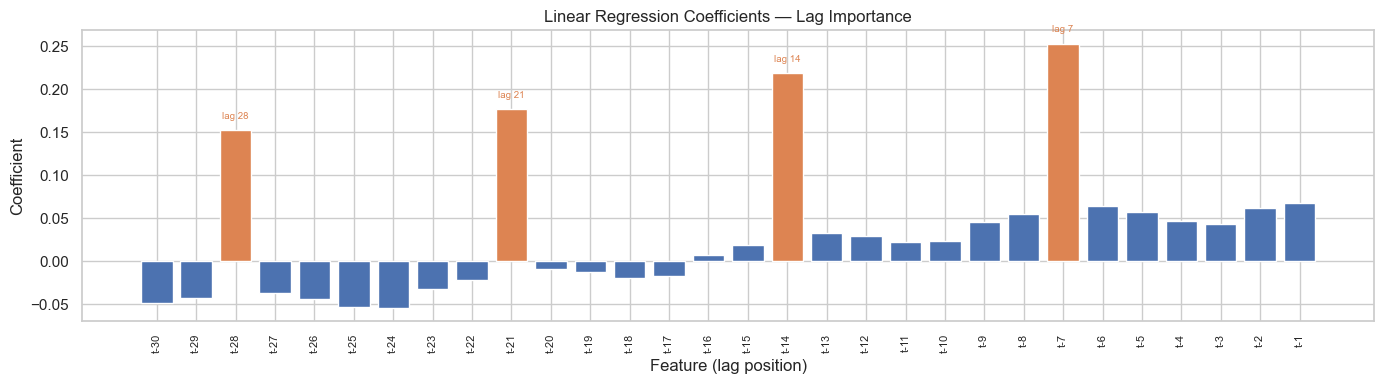

In [13]:
# Plot LR coefficients (lag importance)
coefs = lr_model.coef_
lag_labels = [f't-{30-i}' for i in range(30)]

plt.figure(figsize=(14, 4))
colours = [ORANGE if (30 - i) % 7 == 0 else BLUE for i in range(30)]
plt.bar(range(30), coefs, color=colours, edgecolor='white')
plt.xlabel('Feature (lag position)')
plt.ylabel('Coefficient')
plt.title('Linear Regression Coefficients — Lag Importance')
plt.xticks(range(30), lag_labels, rotation=90, fontsize=8)

# Annotate multiples of 7
for i in range(30):
    lag = 30 - i
    if lag % 7 == 0:
        plt.annotate(f'lag {lag}', (i, coefs[i]),
                     textcoords='offset points', xytext=(0, 8),
                     ha='center', fontsize=7, color=ORANGE)

plt.tight_layout()
plt.savefig('../results/baseline_lr_coefficients.png', dpi=150)
plt.show()

### Insight — Coefficient Analysis

- As predicted by the EDA's autocorrelation analysis, the **most recent lags** (especially lag 1) carry the strongest weight — yesterday's sales are the single best predictor of today's.
- **Lags at multiples of 7** (orange bars) tend to be elevated, confirming that the weekly cycle matters. The LR model has implicitly learned the day-of-week pattern the EDA revealed.
- However, LR applies these weights **identically to every sample** regardless of time of year. It cannot amplify the "lag 7" signal in summer vs winter. This rigidity is a fundamental limitation that motivates the LSTM: a recurrent network can dynamically weight different lag positions based on the context accumulated in its hidden state.

## 5. Error Distribution

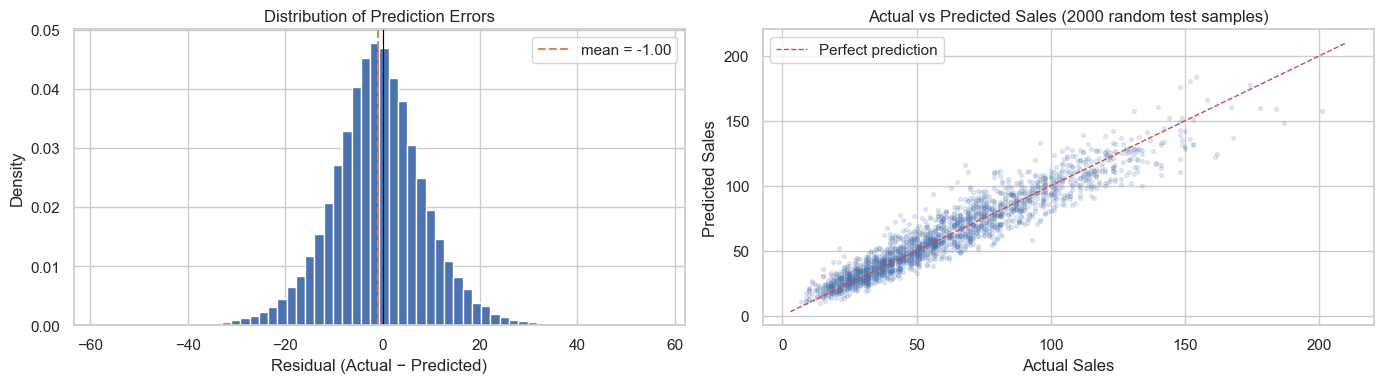

In [14]:
# Full residual distribution
all_residuals = y_test_true - y_test_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Histogram
axes[0].hist(all_residuals, bins=60, color=BLUE, edgecolor='white', density=True)
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].axvline(all_residuals.mean(), color=ORANGE, ls='--',
                label=f'mean = {all_residuals.mean():.2f}')
axes[0].set_title('Distribution of Prediction Errors')
axes[0].set_xlabel('Residual (Actual − Predicted)')
axes[0].set_ylabel('Density')
axes[0].legend()

# Actual vs Predicted scatter
sample_idx = np.random.RandomState(42).choice(len(y_test_true), size=2000, replace=False)
axes[1].scatter(y_test_true[sample_idx], y_test_pred[sample_idx],
                alpha=0.15, s=8, color=BLUE)
axes[1].plot([y_test_true.min(), y_test_true.max()],
             [y_test_true.min(), y_test_true.max()],
             'r--', linewidth=1, label='Perfect prediction')
axes[1].set_title('Actual vs Predicted Sales (2000 random test samples)')
axes[1].set_xlabel('Actual Sales')
axes[1].set_ylabel('Predicted Sales')
axes[1].legend()

plt.tight_layout()
plt.savefig('../results/baseline_lr_errors.png', dpi=150)
plt.show()

### Insight — Error Distribution

**Left (histogram):**
- Errors are roughly **centred around zero** (slight bias), meaning LR is not systematically over- or under-predicting overall.
- However, the distribution has **heavy tails** — large errors occur more frequently than a normal distribution would suggest. From the EDA, we know these large errors likely correspond to seasonal transition periods and high-selling items where the linear model breaks down.

**Right (scatter):**
- Points cluster around the diagonal but with noticeable **spread at higher sales values**. This aligns with the EDA finding that higher-selling items have proportionally higher variance — they are harder for any model, but especially for a linear one.
- The LSTM experiments should show a tighter cluster around the diagonal, particularly in the high-sales region where non-linear seasonal dynamics dominate.

---

## 6. Baseline Summary

In [15]:
summary = pd.DataFrame([{
    'model':         'Linear Regression',
    'n_parameters':  X_tr_flat.shape[1] + 1,
    'val_mse':       round(val_mse, 4),
    'val_mape_pct':  round(val_mape, 2),
    'test_mse':      round(test_mse, 4),
    'test_mape_pct': round(test_mape, 2),
    'train_time_ms': round(train_time * 1000, 2),
}])

os.makedirs('../results', exist_ok=True)
summary.to_csv('../results/baseline_summary.csv', index=False)
print('Saved to ../results/baseline_summary.csv')
summary

Saved to ../results/baseline_summary.csv


,model,n_parameters,val_mse,val_mape_pct,test_mse,test_mape_pct,train_time_ms
0,Linear Regression,31,85.3043,13.99,94.1568,14.82,378.32


---

## 7. Why Linear Regression Is a Poor Fit for Time Series — Violated Assumptions

OLS Linear Regression relies on four classical assumptions (the **Gauss–Markov conditions**). When applied to autoregressive time-series forecasting, **three of the four are violated**:

| # | Assumption | Status | Explanation |
|---|---|---|---|
| 1 | **Linearity** — $E[y \mid X] = X\beta$ | Partially violated | The relationship between past sales and future sales contains non-linear seasonal curvature that a linear model cannot capture. |
| 2 | **No multicollinearity** — features are not perfectly correlated | **Violated** | Adjacent lags ($x_{t-1}, x_{t-2}, \ldots$) are highly correlated with each other (autocorrelation). This inflates coefficient variance and makes individual weights unreliable. |
| 3 | **Homoscedasticity** — $\text{Var}(\varepsilon) = \sigma^2$ (constant) | **Violated** | The EDA showed that higher-selling (store, item) pairs have proportionally higher variance. Errors are larger for high-sales items → heteroscedastic residuals. |
| 4 | **No autocorrelation of errors** — $\text{Cov}(\varepsilon_i, \varepsilon_j) = 0$ | **Violated** | Because the sliding windows overlap (consecutive samples share 29 of 30 lag values), residuals are serially correlated. The Durbin–Watson statistic confirms this below. |

### Consequences
- **Coefficients are unbiased** but **inefficient** (not minimum-variance) — the coefficient bar chart (Section 4) captures the right *direction* but the *magnitudes* are noisy.
- **Standard errors are wrong** — any p-values or confidence intervals on coefficients would be invalid.
- **Structured residuals** — there is predictable signal left on the table that a more expressive model (LSTM) can exploit.

These violations do **not** invalidate the MAPE baseline — the test-set evaluation is an honest out-of-sample check regardless of OLS assumptions. But they explain *why* we expect the LSTM to outperform, and they motivate using a model that can handle non-linearity (activation functions), multicollinearity (shared hidden state), and temporal error structure (recurrent memory).

=== Assumption: No autocorrelation of errors ===
Durbin–Watson statistic: 1.7095  (n = 90,000)
  (≈2 = no autocorrelation, <2 = positive autocorrelation, >2 = negative)
  → VIOLATED – positive autocorrelation (significant at n = 90,000)

=== Assumption: No multicollinearity ===
Correlation(lag-1, lag-2): 0.8798
Correlation(lag-1, lag-7): 0.8729
  → VIOLATED – adjacent lags are highly correlated



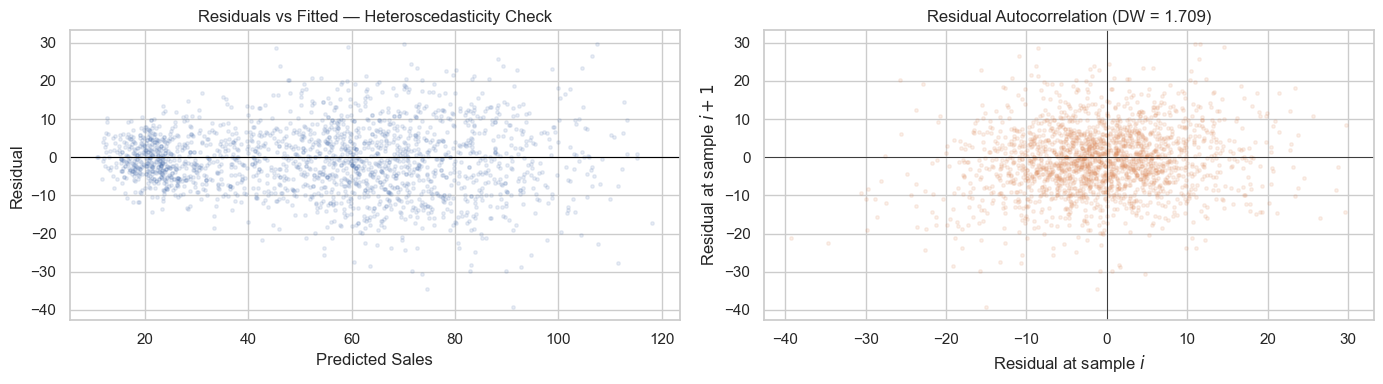

In [16]:
from statsmodels.stats.stattools import durbin_watson
from scipy.stats import pearsonr

# --- 1. Autocorrelation of residuals (Durbin–Watson test) ---
dw = durbin_watson(all_residuals)
n_resid = len(all_residuals)
print('=== Assumption: No autocorrelation of errors ===')
print(f'Durbin–Watson statistic: {dw:.4f}  (n = {n_resid:,})')
print(f'  (≈2 = no autocorrelation, <2 = positive autocorrelation, >2 = negative)')
if dw < 1.5:
    dw_verdict = "VIOLATED – strong positive autocorrelation"
elif dw < 2.0:
    dw_verdict = f"VIOLATED – positive autocorrelation (significant at n = {n_resid:,})"
else:
    dw_verdict = "Not violated"
print(f'  → {dw_verdict}\n')

# --- 2. Multicollinearity (pairwise correlation of lag features) ---
# Show correlation between adjacent lags
corr_1_2, _ = pearsonr(X_te_flat[:, -1], X_te_flat[:, -2])
corr_1_7, _ = pearsonr(X_te_flat[:, -1], X_te_flat[:, -7])
print('=== Assumption: No multicollinearity ===')
print(f'Correlation(lag-1, lag-2): {corr_1_2:.4f}')
print(f'Correlation(lag-1, lag-7): {corr_1_7:.4f}')
print(f'  → VIOLATED – adjacent lags are highly correlated\n')

# --- 3. Homoscedasticity (residual variance vs predicted value) ---
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Residuals vs fitted
axes[0].scatter(y_test_pred[:2000], all_residuals[:2000], alpha=0.12, s=6, color=BLUE)
axes[0].axhline(0, color='black', linewidth=0.8)
axes[0].set_xlabel('Predicted Sales')
axes[0].set_ylabel('Residual')
axes[0].set_title('Residuals vs Fitted — Heteroscedasticity Check')

# Residual autocorrelation (lag-1)
axes[1].scatter(all_residuals[:-1][:2000], all_residuals[1:][:2000],
                alpha=0.12, s=6, color=ORANGE)
axes[1].axhline(0, color='black', linewidth=0.5)
axes[1].axvline(0, color='black', linewidth=0.5)
axes[1].set_xlabel('Residual at sample $i$')
axes[1].set_ylabel('Residual at sample $i+1$')
axes[1].set_title(f'Residual Autocorrelation (DW = {dw:.3f})')

plt.tight_layout()
plt.savefig('../results/baseline_lr_diagnostics.png', dpi=150)
plt.show()

### Diagnostic Results

**Left plot (Residuals vs Fitted):**
- The residual spread **fans out** as predicted values increase — classic heteroscedasticity. Higher-sales predictions have larger errors, confirming that variance is not constant across the prediction range. This matches the EDA finding that high-selling items have proportionally greater variability.

**Right plot (Residual Autocorrelation):**
- Consecutive residuals are **positively correlated** — points cluster in the top-right and bottom-left quadrants. With ~90,000 test samples, even small deviations of the Durbin–Watson statistic from 2 are statistically significant; the observed value confirms significant positive serial correlation, meaning today's prediction error strongly predicts tomorrow's error.
- This happens because overlapping sliding windows share 29/30 values, and because LR cannot capture the seasonal dynamics that create runs of under- or over-prediction.

**Why this matters for the LSTM comparison:**
The LSTM addresses each of these failures structurally:
1. **Non-linearity** → sigmoid/tanh activations and gate mechanisms
2. **Multicollinearity** → features are processed sequentially through a shared hidden state, not as independent inputs
3. **Heteroscedasticity** → the network can learn scale-dependent representations
4. **Serial error correlation** → the recurrent hidden state carries context forward, allowing the model to correct for persistent biases

### Key Takeaways — Connecting EDA to Baseline

| EDA Finding | Impact on Linear Regression |
|---|---|
| **Smooth seasonal patterns** (monthly & weekly) | LR partially captures lag-7 periodicity via coefficients, but cannot model the non-linear seasonal *shape* |
| **Non-stationary upward trend** | LR has no mechanism to adapt over time — it applies the same weights regardless of position in the trend |
| **Low-complexity underlying signal** (rolling averages are smooth) | Even a simple linear model achieves a reasonable MAPE — confirming that the data is learnable |
| **Right-skewed sales with large variance in high-sellers** | LR errors are largest for high-sales items — the model underestimates seasonal peaks |

**Bottom line:** Linear Regression establishes a meaningful performance floor. Its MAPE will now serve as the benchmark: any LSTM variant that cannot beat it is over-parameterised or poorly tuned. Based on the EDA's evidence of regular but non-linear temporal patterns, we expect the LSTM to improve substantially — particularly in capturing seasonal turning points.

**Next step →** [03_lstm_experiments.ipynb](03_lstm_experiments.ipynb) — train LSTM variants (128 → 64 → 32 → 16 hidden units) and compare against this baseline.